<a href="https://colab.research.google.com/github/antoniopedro98/antoniopsalves.github.io/blob/main/pasta/Resolvido_03_Prevendo_Gols_Mandante_Brasileirao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Oficina de Inteligência Artificial Aplicada à Análise de Dados de Futebol**

# Projeto Final
Projeto final para conclusão da Oficina de Inteligência Artificial Aplicada à Análise de Dados de Futebol

## Previsão de Gols do Mandante (Brasileirão 2003-2024)

Neste notebook, queremos **prever a quantidade de gols do time mandante**. Para isso, temos uma base de dados que inclui dados de **todas as partidas do Brasileirão entre 2003 e 2024**. Os dados disponíveis permitem a comparação entre fatores que influenciam o resultado, em gols, da partida.



## Importando as Bibliotecas

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme()


## Coleta dos Dados

Coletando os dados do Brasileirão a partir do arquivo `.CSV`

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/antoniopedro98/oficina-ia-puc-rio-2026-1/refs/heads/main/dataset_brasileirao_historico_2003_2024.csv", low_memory=False)
df.head()

,ano_campeonato,data,rodada,estadio,arbitro,publico,publico_max,time_mandante,time_visitante,tecnico_mandante,...,chutes_bola_parada_mandante,chutes_bola_parada_visitante,defesas_mandante,defesas_visitante,impedimentos_mandante,impedimentos_visitante,chutes_mandante,chutes_visitante,chutes_fora_mandante,chutes_fora_visitante
0,2005,2005-10-08,31,Estádio Durival Britto e Silva,NaN,NaN,NaN,Paraná,Fluminense,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005,2005-04-23,1,Estádio Durival Britto e Silva,NaN,NaN,NaN,Paraná,Goiás EC,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2005,2005-08-21,21,Estádio Durival Britto e Silva,NaN,NaN,NaN,Paraná,Vasco da Gama,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2005,2005-08-28,23,Estádio Durival Britto e Silva,NaN,NaN,NaN,Paraná,São Paulo,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2005,2005-06-26,9,Estádio Olímpico Nilton Santos,NaN,NaN,NaN,Botafogo,Figueirense FC,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Visão geral do dataset

In [ ]:
# qual o total de entradas do nosso dado (linhas, colunas)
print(f"Total de dados: {df.shape}")

Total de dados: (8453, 35)


In [ ]:
# informações gerais do dataframe
print(f"Informações do DataFrame: {df.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8453 entries, 0 to 8452
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ano_campeonato                  8453 non-null   int64  
 1   data                            8453 non-null   object 
 2   rodada                          8453 non-null   int64  
 3   estadio                         8442 non-null   object 
 4   arbitro                         6743 non-null   object 
 5   publico                         6742 non-null   float64
 6   publico_max                     4181 non-null   float64
 7   time_mandante                   8453 non-null   object 
 8   time_visitante                  8453 non-null   object 
 9   tecnico_mandante                6299 non-null   object 
 10  tecnico_visitante               6299 non-null   object 
 11  colocacao_mandante              6743 non-null   float64
 12  colocacao_visitante             67

## Quantidade de Dados Faltantes

Vamos checar rapidamente quais colunas possuem valores faltantes e qual o percentual em relação ao total de linhas.

In [ ]:
faltantes = df.isnull().sum().sort_values(ascending=False)
percentual_faltantes = (faltantes / len(df) * 100).round(2)
faltantes_df = pd.DataFrame({"Faltantes": faltantes, "Percentual": percentual_faltantes})
faltantes_df = faltantes_df[faltantes_df["Faltantes"] > 0]
faltantes_df.head(20)


,Faltantes,Percentual
chutes_fora_visitante,6366,75.31
defesas_visitante,6366,75.31
defesas_mandante,6366,75.31
faltas_mandante,6366,75.31
faltas_visitante,6366,75.31
chutes_bola_parada_visitante,6366,75.31
chutes_fora_mandante,6366,75.31
impedimentos_visitante,6366,75.31
impedimentos_mandante,6366,75.31
chutes_visitante,6366,75.31


## Percentual de Valores Únicos

Esse indicador ajuda a identificar colunas com alta cardinalidade (ex.: nomes, IDs) que podem atrapalhar o modelo se forem usadas do jeito errado.

In [ ]:
def percentual_valores_unicos(df_):
    rows = []
    for col in df_.columns:
        rows.append({
            "Coluna": col,
            "Únicos": df_[col].nunique(dropna=True),
            "Percentual Unicos": round(df_[col].nunique(dropna=True) / len(df_) * 100, 2)
        })
    return pd.DataFrame(rows).sort_values("Percentual Unicos", ascending=False)


In [ ]:
percentual_valores_unicos(df).head(15)

,Coluna,Únicos,Percentual Unicos
5,publico,5408,63.98
1,data,2107,24.93
13,valor_equipe_titular_mandante,1629,19.27
14,valor_equipe_titular_visitante,1624,19.21
9,tecnico_mandante,259,3.06
10,tecnico_visitante,254,3.00
4,arbitro,209,2.47
6,publico_max,155,1.83
16,idade_media_titular_visitante,111,1.31
15,idade_media_titular_mandante,111,1.31


## Definindo a variável alvo (y)

No nosso dataset, o gol do mandante está em `gols_mandante`:

In [ ]:
target_col = "gols_mandante"
df[target_col].describe()

,gols_mandante
count,8452.000000
mean,1.528159
std,1.218342
min,0.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,7.000000


## Exploração (EDA)

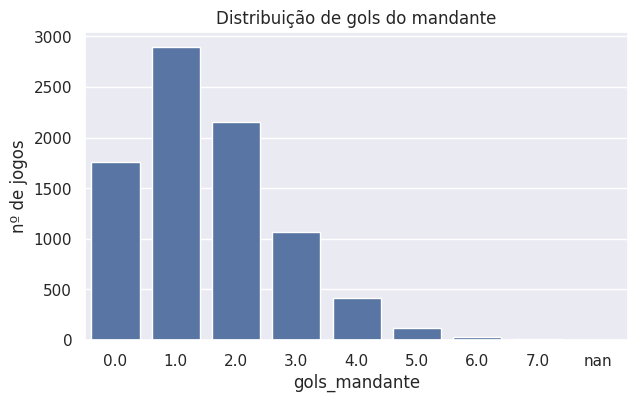

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(x='gols_mandante', data=df, order=sorted(df['gols_mandante'].unique()))
plt.title("Distribuição de gols do mandante")
plt.xlabel("gols_mandante")
plt.ylabel("nº de jogos")
plt.show()

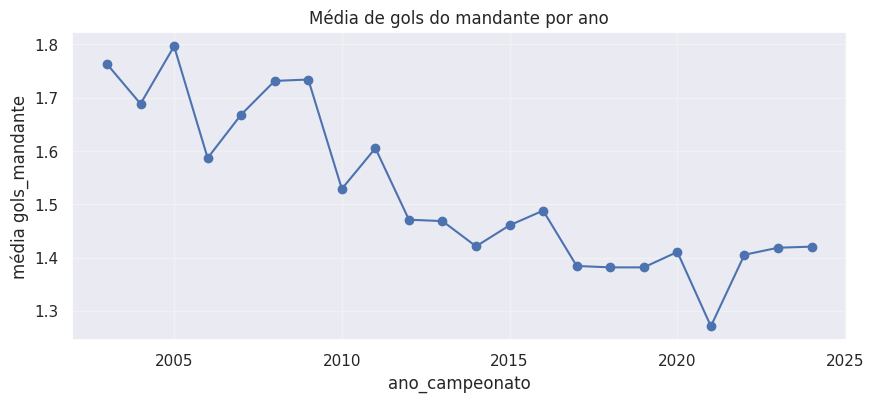

,gols_mandante
ano_campeonato,
2003,1.763158
2004,1.688596
2005,1.796651
2006,1.586842
2007,1.668421


In [ ]:
gols_por_ano = df.groupby('ano_campeonato')['gols_mandante'].mean().sort_index()

plt.figure(figsize=(10,4))
plt.plot(gols_por_ano.index, gols_por_ano.values, marker='o')
plt.title("Média de gols do mandante por ano")
plt.xlabel("ano_campeonato")
plt.ylabel("média gols_mandante")
plt.grid(True, alpha=0.3)
plt.show()

gols_por_ano.head()

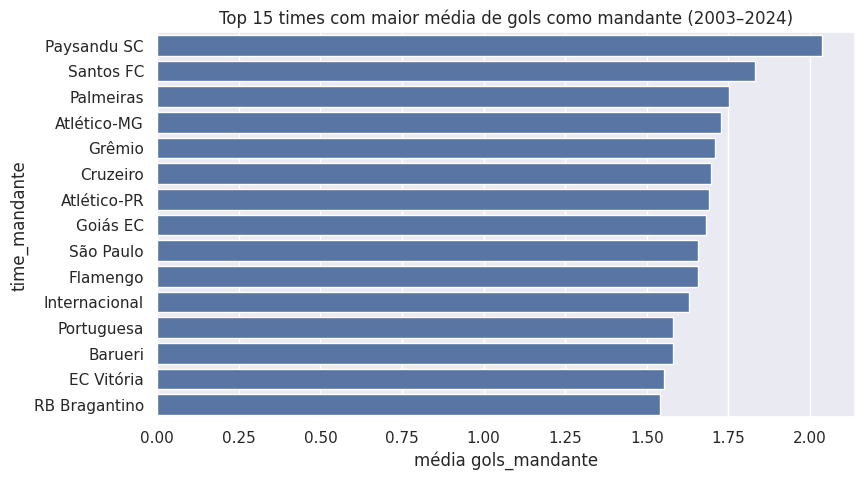

In [ ]:
top_times_casa = (df.groupby('time_mandante')['gols_mandante']
                  .mean()
                  .sort_values(ascending=False)
                  .head(15))

plt.figure(figsize=(9,5))
sns.barplot(x=top_times_casa.values, y=top_times_casa.index)
plt.title("Top 15 times com maior média de gols como mandante (2003–2024)")
plt.xlabel("média gols_mandante")
plt.ylabel("time_mandante")
plt.show()

In [ ]:
display(top_times_casa)

,gols_mandante
time_mandante,
Paysandu SC,2.035088
Santos FC,1.830409
Palmeiras,1.752000
Atlético-MG,1.725888
Grêmio,1.707447
Cruzeiro,1.697479
Atlético-PR,1.691228
Goiás EC,1.681452
São Paulo,1.657005


# Preparação dos Dados

Vamos:

0) Converter a data do jogo para um tipo chamado `Datetime`
1) Separar X e y
2) Remover colunas que vazam a resposta (ex.: `gols_mandante`no X) e colunas irrelevantes/IDs óbvios
3) Criar um pipeline com pré-processamento (imputação + encoding)

In [ ]:
# 0) Converter para datetime
df["data"] = pd.to_datetime(df["data"], errors="coerce", utc=True)
df["ano"] = df["data"].dt.year
# mês e dia da semana podem capturar sazonalidade (ex.: começo vs fim de temporada)
df["mes"] = df["data"].dt.month
df["dia_semana"] = df["data"].dt.dayofweek

In [ ]:
# 0.1) checar possiveis duplicatas
df = df.drop_duplicates()

In [ ]:
# 1) Separando X e y
y = df[target_col]
X = df.drop(columns=[target_col])

In [ ]:
# 2) Removendo colunas 'desnecessarias' para nosso modelo
drop_cols =[c for c in df.columns if 'gols_' in c or 'chutes' in c or 'defesas' in c]  # resultado e gols finais
print("Removendo colunas:", drop_cols)
X = X.drop(columns=drop_cols, errors="ignore")

Removendo colunas: ['gols_mandante', 'gols_visitante', 'gols_1_tempo_mandante', 'gols_1_tempo_visitante', 'chutes_bola_parada_mandante', 'chutes_bola_parada_visitante', 'defesas_mandante', 'defesas_visitante', 'chutes_mandante', 'chutes_visitante', 'chutes_fora_mandante', 'chutes_fora_visitante']


In [ ]:
# nosso X, agora, tem menos atributos
print(f"Atualização na dimensão do X: {X.shape}")

Atualização na dimensão do X: (8453, 26)


## Separando treino e teste (temporal)

## Split temporal por temporadas

Vamos usar as **3 últimas temporadas** como teste (2022, 2023, 2024), e o restante como treino. Isso é um pouco diferente do tradicional 80/20, pois aqui, a data do evento é importante.

In [ ]:
# Divisão temporal: Treino (passado) e Teste (futuro)
# Usamos uma máscara (filtro) booleana
train_mask = df['ano_campeonato'] <= 2021
test_mask = df['ano_campeonato'] >= 2022

# Split padrão sklearn
X_train = X.loc[train_mask]
y_train = y.loc[train_mask]
X_test = X.loc[test_mask]
y_test = y.loc[test_mask]

print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("\nDistribuição treino:")
print(y_train.value_counts(normalize=True))
print("\nDistribuição teste:")
print(y_test.value_counts(normalize=True))

Treino: (7410, 26) | Teste: (1043, 26)

Distribuição treino:
gols_mandante
1.0    0.339047
2.0    0.256040
0.0    0.205696
3.0    0.129167
4.0    0.050479
5.0    0.014577
6.0    0.004184
7.0    0.000810
Name: proportion, dtype: float64

Distribuição teste:
gols_mandante
1.0    0.370086
2.0    0.245446
0.0    0.223394
3.0    0.107383
4.0    0.040268
5.0    0.011505
7.0    0.000959
6.0    0.000959
Name: proportion, dtype: float64


## Pipeline de Pré-processamento + Modelo

In [ ]:
# Separando colunas numéricas e categóricas
atributos_numericos = X_train.select_dtypes(include=[np.number]).columns.tolist()
atributos_categoricos = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Atributos Numéricos: {atributos_numericos}")
print(f"Atributos Categóricos: {atributos_categoricos}")

Atributos Numéricos: ['ano_campeonato', 'rodada', 'publico', 'publico_max', 'colocacao_mandante', 'colocacao_visitante', 'valor_equipe_titular_mandante', 'valor_equipe_titular_visitante', 'idade_media_titular_mandante', 'idade_media_titular_visitante', 'escanteios_mandante', 'escanteios_visitante', 'faltas_mandante', 'faltas_visitante', 'impedimentos_mandante', 'impedimentos_visitante', 'ano', 'mes', 'dia_semana']
Atributos Categóricos: ['data', 'estadio', 'arbitro', 'time_mandante', 'time_visitante', 'tecnico_mandante', 'tecnico_visitante']


In [ ]:
# transformadores dos dados, padronizando eles
transformador_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False)),
])

transformador_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico, atributos_numericos),
        ("cat", transformador_categorico, atributos_categoricos),
    ],
    remainder="drop"
)


In [ ]:
def avaliar_regressao(modelo, X_tr, y_tr, X_te, y_te, nome="modelo"):
    modelo.fit(X_tr, y_tr)
    pred_tr = modelo.predict(X_tr)
    pred_te = modelo.predict(X_te)

    resultados = {
        "modelo": nome,
        "MAE_train": mean_absolute_error(y_tr, pred_tr),
        "RMSE_train": np.sqrt(mean_squared_error(y_tr, pred_tr)),
        "R2_train": r2_score(y_tr, pred_tr),
        "MAE_test": mean_absolute_error(y_te, pred_te),
        "RMSE_test": np.sqrt(mean_squared_error(y_te, pred_te)),
        "R2_test": r2_score(y_te, pred_te),
    }
    return resultados, pred_te


## Modelo 0: Baseline (DummyRegressor)

In [ ]:
# nosso Y tem valores nulos (e pro modelo isso é terrível)
y_train_cleaned = y_train.dropna()
X_train_cleaned = X_train.loc[y_train_cleaned.index]

In [ ]:

dummy = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', DummyRegressor(strategy='mean'))
])

res_dummy, pred_dummy = avaliar_regressao(dummy, X_train_cleaned, y_train_cleaned, X_test, y_test, nome="Dummy (média)")
res_dummy

{'modelo': 'Dummy (média)',
 'MAE_train': 1.0042929662010913,
 'RMSE_train': np.float64(1.2261917315814281),
 'R2_train': 0.0,
 'MAE_test': 0.9627225160971983,
 'RMSE_test': np.float64(1.1613379806155402),
 'R2_test': -0.012692138520063567}

## Modelo 1: Regressão Ridge

In [ ]:
ridge_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', Ridge(alpha=3.0, random_state=42))
])

res_ridge, pred_ridge = avaliar_regressao(ridge_model,X_train_cleaned, y_train_cleaned, X_test, y_test, nome="Ridge")
res_ridge


{'modelo': 'Ridge',
 'MAE_train': 0.8091913469941583,
 'RMSE_train': np.float64(1.0245702759968784),
 'R2_train': 0.30182107036741124,
 'MAE_test': 0.8931932978657016,
 'RMSE_test': np.float64(1.1723723618135724),
 'R2_test': -0.0320276254567009}

## Modelo 2 — Random Forest Regressor

In [ ]:
rf_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=10,
        random_state=42,
        n_jobs=-1,
        max_depth=25,
        min_samples_leaf=5
    ))
])

res_rf, pred_rf = avaliar_regressao(rf_model, X_train_cleaned, y_train_cleaned, X_test, y_test, nome="RandomForest")
res_rf

{'modelo': 'RandomForest',
 'MAE_train': 0.7107322667841361,
 'RMSE_train': np.float64(0.9210900870997838),
 'R2_train': 0.4357293645795757,
 'MAE_test': 0.920427391484728,
 'RMSE_test': np.float64(1.1491318485992565),
 'R2_test': 0.008483598949991622}

## Comparação dos modelos

In [ ]:
resultados = pd.DataFrame([res_dummy, res_ridge, res_rf]).set_index("modelo")
resultados


,MAE_train,RMSE_train,R2_train,MAE_test,RMSE_test,R2_test
modelo,,,,,,
Dummy (média),1.004293,1.226192,0.000000,0.962723,1.161338,-0.012692
Ridge,0.809191,1.024570,0.301821,0.893193,1.172372,-0.032028
RandomForest,0.710732,0.921090,0.435729,0.920427,1.149132,0.008484


## Visualização: Real vs Previsto


Um gráfico simples para comparar valores reais e previstos no conjunto de teste.

In [ ]:
modelo_visualizar_pred = pred_ridge

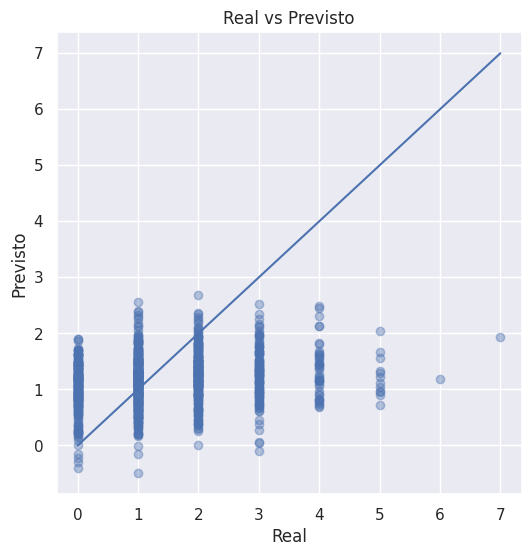

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, modelo_visualizar_pred, alpha=0.4)
plt.xlabel("Real")
plt.ylabel("Previsto")
plt.title("Real vs Previsto")
# linha y=x
mn = min(y_test.min(), pred_rf.min())
mx = max(y_test.max(), pred_rf.max())
plt.plot([mn, mx], [mn, mx])
plt.show()


# Conclusão

Neste notebook, nós:
- Carregamos e exploramos a base de jogos do Brasileirão entre 2003 e 2024
- Definimos a variável alvo (gols mandante)
- Criamos um pipeline de pré-processamento (numérico + categórico)
- Treinamos e avaliamos dois modelos (Regressão Ridge e RandomForest)
- Fizemos visualizações para interpretar resultados

**Sugestão para o relatório do grupo:** inclua 3 visualizações (EDA + real vs previsto + importância de features) e discuta quais variáveis parecem mais relevantes. Além disso, pense em quais foram os desafios e soluções que vocês encontraram.